## Hồi quy đa thức (Polynomial Regression) trên tập dữ liệu Boston Housing

**Trong notebook này chúng ta thực hiện so sánh độ chính xác giữa Hồi quy tuyến tính (Linear Regression) và Hồi quy đa thức (Polynomial Regression) trên tập dữ liệu Boston Housing**

Dữ liệu này ban đầu là một phần của UCI Machine Learning Repository và hiện đã bị gỡ bỏ. Dữ liệu này cũng được đóng gói sẵn trong thư viện scikit-learn.
Có 506 mẫu và 13 biến đặc trưng (feature) trong tập dữ liệu này. Mục tiêu là dự đoán giá nhà dựa trên các đặc trưng đã cho.

Mô tả của tất cả các đặc trưng được liệt kê dưới đây:

  **CRIM**: Tỷ lệ tội phạm bình quân đầu người theo từng thị trấn

  **ZN**: Tỷ lệ đất ở được quy hoạch cho các lô đất trên 25.000 sq. ft (feet vuông)

  **INDUS**: Tỷ lệ diện tích đất kinh doanh phi bán lẻ (mẫu Anh) trên mỗi thị trấn

  **CHAS**: Biến giả sông Charles (= 1 nếu khu đất giáp sông; ngược lại = 0)

  **NOX**: Nồng độ oxit nitric (phần trên 10 triệu)

  **RM**: Số phòng trung bình mỗi căn nhà

  **AGE**: Tỷ lệ căn nhà do chủ sở hữu ở, được xây trước năm 1940

  **DIS**: Khoảng cách có trọng số đến năm trung tâm việc làm của Boston

  **RAD**: Chỉ số khả năng tiếp cận các đường cao tốc hướng tâm

  **TAX**: Thuế bất động sản theo giá trị đầy đủ trên mỗi $10.000

  **B**: 1000(Bk - 0,63)², trong đó Bk là tỷ lệ [người gốc Phi] theo từng thị trấn

  **LSTAT**: Tỷ lệ phần trăm dân số có địa vị thấp

  **MEDV**: Giá trị trung vị của nhà do chủ sở hữu ở, tính theo đơn vị $1000
  
  
  


**Import các thư viện cần thiết**

In [0]:
import numpy as np
import matplotlib.pyplot as plt 

import pandas as pd  
import seaborn as sns 

%matplotlib inline

**Tải tập dữ liệu Boston Housing từ scikit-learn**

In [ ]:
from sklearn.datasets import load_boston

boston_dataset = load_boston()

# boston_dataset là một dictionary (từ điển)
# hãy kiểm tra xem nó chứa gì
boston_dataset.keys()

**Nạp dữ liệu vào pandas dataframe**

In [3]:
boston = pd.DataFrame(boston_dataset.data, columns=boston_dataset.feature_names)
boston.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


**Giá trị mục tiêu (target) bị thiếu trong dữ liệu. Tạo một cột giá trị mục tiêu mới và thêm vào dataframe**

In [0]:
boston['MEDV'] = boston_dataset.target

**Tiền xử lý dữ liệu**

In [ ]:
# kiểm tra giá trị thiếu (missing) trong tất cả các cột
boston.isnull().sum()

**Trực quan hóa dữ liệu**

In [ ]:
# thiết lập kích thước của hình vẽ
sns.set(rc={'figure.figsize':(11.7,8.27)})

# vẽ biểu đồ histogram thể hiện phân phối của giá trị mục tiêu
sns.distplot(boston['MEDV'], bins=30)
plt.show()

**Ma trận tương quan**

In [ ]:
# tính tương quan cặp đôi cho tất cả các cột
correlation_matrix = boston.corr().round(2)

In [ ]:
# sử dụng hàm heatmap của seaborn để vẽ ma trận tương quan
# annot = True để in giá trị bên trong mỗi ô vuông
sns.heatmap(data=correlation_matrix, annot=True)

**Nhận xét**




*   Từ biểu đồ tương quan phía trên ta thấy **MEDV** có tương quan mạnh với **LSTAT**, **RM**

*  **RAD** và **TAX** có tương quan mạnh với nhau, nên chúng ta không đưa cả hai vào cùng lúc trong tập đặc trưng để tránh đa cộng tuyến (multi-colinearity)



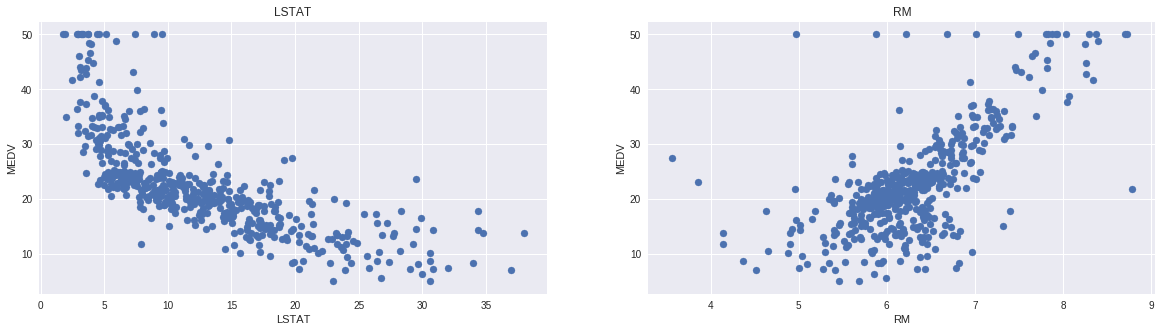

In [9]:
plt.figure(figsize=(20, 5))

features = ['LSTAT', 'RM']
target = boston['MEDV']

for i, col in enumerate(features):
    plt.subplot(1, len(features) , i+1)
    x = boston[col]
    y = target
    plt.scatter(x, y, marker='o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('MEDV')

**Chuẩn bị dữ liệu để huấn luyện**

In [0]:
X = pd.DataFrame(np.c_[boston['LSTAT'], boston['RM']], columns = ['LSTAT','RM'])
Y = boston['MEDV']

**Chia dữ liệu thành tập huấn luyện và tập kiểm tra**

In [ ]:
from sklearn.model_selection import train_test_split

# chia tập huấn luyện và tập kiểm tra theo tỷ lệ 80% : 20%
# gán random_state bằng một giá trị bất kỳ để đảm bảo tính nhất quán (consistency)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state=5)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

# **Hồi quy tuyến tính (Linear Regression)**

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train, Y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=1, normalize=False)

In [ ]:
# đánh giá mô hình trên tập huấn luyện

y_train_predict = lin_model.predict(X_train)
rmse = (np.sqrt(mean_squared_error(Y_train, y_train_predict)))
r2 = r2_score(Y_train, y_train_predict)

print("Hiệu năng của mô hình trên tập huấn luyện")
print("--------------------------------------")
print('RMSE là {}'.format(rmse))
print('Điểm R2 là {}'.format(r2))
print("\n")

# đánh giá mô hình trên tập kiểm tra

y_test_predict = lin_model.predict(X_test)
# sai số căn bậc hai trung bình bình phương của mô hình
rmse = (np.sqrt(mean_squared_error(Y_test, y_test_predict)))

# điểm R-squared của mô hình
r2 = r2_score(Y_test, y_test_predict)

print("Hiệu năng của mô hình trên tập kiểm tra")
print("--------------------------------------")
print('RMSE là {}'.format(rmse))
print('Điểm R2 là {}'.format(r2))

In [ ]:
# vẽ biểu đồ y_test so với y_pred
# lý tưởng thì nó phải là một đường thẳng
plt.scatter(Y_test, y_test_predict)
plt.show()

# **Hồi quy đa thức (Polynomial Regression)**

Ta thấy rằng **LSTAT** không biến đổi hoàn toàn theo quy luật tuyến tính. Hãy áp dụng Hồi quy đa thức với **bậc 2 (degree 2)** và kiểm tra.

Để sinh ra các đặc trưng bậc cao hơn, ta dùng class PolynomialFeatures từ thư viện sklearn. 

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

def create_polynomial_regression_model(degree):
  "Tạo một mô hình hồi quy đa thức cho bậc (degree) đã cho"
  poly_features = PolynomialFeatures(degree=degree)
  
  # biến đổi các đặc trưng thành đặc trưng bậc cao hơn.
  X_train_poly = poly_features.fit_transform(X_train)
  
  # khớp các đặc trưng đã biến đổi với Hồi quy tuyến tính
  poly_model = LinearRegression()
  poly_model.fit(X_train_poly, Y_train)
  
  # dự đoán trên tập huấn luyện
  y_train_predicted = poly_model.predict(X_train_poly)
  
  # dự đoán trên tập kiểm tra
  y_test_predict = poly_model.predict(poly_features.fit_transform(X_test))
  
  # đánh giá mô hình trên tập huấn luyện
  rmse_train = np.sqrt(mean_squared_error(Y_train, y_train_predicted))
  r2_train = r2_score(Y_train, y_train_predicted)
  
  # đánh giá mô hình trên tập kiểm tra
  rmse_test = np.sqrt(mean_squared_error(Y_test, y_test_predict))
  r2_test = r2_score(Y_test, y_test_predict)
  
  print("Hiệu năng của mô hình trên tập huấn luyện")
  print("-------------------------------------------")
  print("RMSE của tập huấn luyện là {}".format(rmse_train))
  print("Điểm R2 của tập huấn luyện là {}".format(r2_train))
  
  print("\n")
  
  print("Hiệu năng của mô hình trên tập kiểm tra")
  print("-------------------------------------------")
  print("RMSE của tập kiểm tra là {}".format(rmse_test))
  print("Điểm R2 của tập kiểm tra là {}".format(r2_test))

In [57]:
create_polynomial_regression_model(2)

The model performance for the training set
-------------------------------------------
RMSE of training set is 4.703071027847756
R2 score of training set is 0.7425094297364765


The model performance for the test set
-------------------------------------------
RMSE of test set is 3.784819884545044
R2 score of test set is 0.8170372495892174


**Ta có thể quan sát thấy sai số đã giảm khi sử dụng hồi quy đa thức so với hồi quy tuyến tính**